# Project 1 — Task 1: understand, audit, and prepare the data

**Prediction question.** Can information available when a charging session begins predict whether it will terminate abnormally? The outcome is binary (`is_Abnormal`), and a useful solution must make its decision at session start. This notebook addresses Task 1 of the [assignment](TP1-MINDD2026_27-Task1.pdf): understand the supplied data, investigate quality and temporal change, then justify a preparation strategy. Classification models belong to later work.

This notebook follows a question → evidence → interpretation → decision rhythm, like the course example. The [dataset guide](docs/DATASET.md) explains every original field. **Label assumption:** the CSV has only `end_cause`, so we derive `is_Abnormal` in memory: an ordinary completion or a user-requested stop is normal (0); the 13 fault/failure causes are abnormal (1). This is our explicit interpretation, not a mapping supplied by the PDF. We quantify its sensitivity below.

## 1. Load the original data

We first read the source file without modifying it. Relative paths let every teammate run the same notebook from the repository root. The CSV is about 179 MB, so loading it once is more efficient than repeatedly reading it. We display only aggregate information: user IDs and individual rows are unnecessary for this audit.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})

path = Path("Charging_Data_educational.csv")
assert path.exists(), "Place the original CSV beside main.ipynb before running."
df = pd.read_csv(path)
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Memory after loading: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Rows: 441,077 | Columns: 47


Memory after loading: 370.0 MB


**Interpretation.** The supplied file has 441,077 sessions and 47 columns. This matches the transaction count quoted for the original research dataset, although we still treat the educational CSV as a distinct source. We retain the full source in memory for auditing; we have not filtered any sessions.

## 2. Check the schema and define the target

A classification analysis needs an exact outcome. The next table records each original column's loaded type, missing values, and number of distinct values. Distinct counts are diagnostic, not an instruction to encode IDs as numbers. We then examine every termination reason before mapping it.

In [2]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "distinct": df.nunique(dropna=True),
})
display(schema)
print("is_Abnormal present:", "is_Abnormal" in df.columns)
print("end_cause categories:", df["end_cause"].nunique())
display(df["end_cause"].value_counts().rename_axis("end_cause").to_frame("sessions"))

,dtype,missing,missing_%,distinct
UserID,int64,0,0.00,56115
Charging Post ID,int64,0,0.00,92
Location Information,str,0,0.00,13
District Name,str,0,0.00,3
Order creation time,str,0,0.00,438764
Transaction power/kwh,float64,0,0.00,7053
Electricity cost/Yuan,float64,0,0.00,6320
Service charge/Yuan,float64,0,0.00,5129
Transaction Amount/Yuan,float64,0,0.00,8487
Actual Payment/Yuan,float64,0,0.00,8412


is_Abnormal present: False
end_cause categories: 15


,sessions
end_cause,
Charging ends normally,203201
User stops charging,155942
Other faults of the charging pile,20114
DC Output Fault,14813
Vehicle communications failure,13936
Faulty charging connection,8539
BMS failure,8170
Failure of non-system control loop components and assemblies,6941
Vehicle charging faults,6429


**Interpretation.** There are 15 termination reasons, but no original `is_Abnormal` column. The labels describe two non-fault endings and 13 fault/failure endings. We treat a user-requested stop as a normal, intentional end. Because the PDF does not prescribe this rule, we keep it visible and compare it with the alternative of counting those stops as abnormal. The raw `end_cause` is an outcome observed after the session; it can never be a predictor.

### Define and inspect the binary flag

We assign 0 to `Charging ends normally` and `User stops charging`, and 1 to the remaining recorded fault/failure reasons. We check for unknown or missing causes before doing so. The derived column exists in memory only; the original CSV is unchanged.

In [3]:
normal_causes = {"Charging ends normally", "User stops charging"}
observed_causes = set(df["end_cause"].dropna().unique())
fault_causes = observed_causes - normal_causes
assert df["end_cause"].notna().all(), "Review missing end causes before assigning labels."
assert normal_causes <= observed_causes, "Expected normal cause is absent."
assert len(fault_causes) == 13 and all(
    ("fault" in cause.lower() or "failure" in cause.lower()) for cause in fault_causes
), "Review changed or unknown end causes before assigning labels."
df["is_Abnormal"] = df["end_cause"].isin(fault_causes).astype("int8")
class_counts = df["is_Abnormal"].value_counts().sort_index()
display(pd.DataFrame({"sessions": class_counts,
                      "share_%": (class_counts / len(df) * 100).round(2)}))
print("Alternative abnormal share if user stops were abnormal:"
      f" {(~df['end_cause'].eq('Charging ends normally')).mean() * 100:.2f}%")

,sessions,share_%
is_Abnormal,,
0,359143,81.42
1,81934,18.58


Alternative abnormal share if user stops were abnormal: 53.93%


**Interpretation and decision.** Under the stated rule, 81,934 sessions (18.58%) are abnormal and 359,143 (81.42%) are normal. If we counted the 155,942 user stops as abnormal instead, the abnormal share would rise to 53.93%. That large shift matters for every later model and metric. We proceed with fault/failure as “abnormal” for this exploratory task and record the mapping as an assumption requiring instructor confirmation before final modelling claims. The code fails if a new or missing cause appears rather than silently labeling it.

### Prediction-time feature audit

The table is a policy based on the assignment's timing rule, not a data-driven feature selection. We keep excluded fields in the audit data because they help check quality, but we do not put them in a model input table.

| Field group | Prediction-time status | Reason or question to resolve |
| --- | --- | --- |
| Location, district, start timestamp, electricity price, tariff interval | Candidate | Described as known at session start; derive calendar features only from start time. |
| Temperature, humidity, precipitation | Candidate under the PDF's forecast assumption | The assignment explicitly says to treat these as start-time estimates/forecasts. Real deployment would need such a feed. |
| `post_*`, `user_*`, `is_new_user`, `user_active_sessions_at_start` | Candidate with caveats | Provided histories use prior completed outcomes; verify definitions, operational availability, cold starts, and privacy. No need to reconstruct them. |
| `UserID`, `Charging Post ID` | Audit keys first | They are available but may encourage memorisation and weaken transfer to new users/posts; decide predictive use after evaluation design. |
| `Order creation time` | Conditional | Potentially known at start, but its ordering disagrees with start time in many records; investigate before deriving features. |
| `end_cause`, `End Time`, `Payment time`, transaction energy, costs, amount, actual payment | Excluded from predictors | These describe the completed transaction or its outcome. Even if correlated with abnormality, they are not available at prediction time. |

## 3. Time coverage and event order

Timestamps establish the observation period and reveal whether event ordering is plausible. We parse all four timestamps without silently dropping parsing failures. A negative difference means the second event is recorded before the first; it is a flag for investigation, not automatic proof that either row is wrong.

In [4]:
times = {name: pd.to_datetime(df[name], errors="coerce") for name in
         ["Order creation time", "Start Time", "End Time", "Payment time"]}
coverage = pd.DataFrame({
    "earliest": {name: s.min() for name, s in times.items()},
    "latest": {name: s.max() for name, s in times.items()},
    "unparseable": {name: s.isna().sum() for name, s in times.items()},
})
display(coverage)
order_rows = []
for earlier, later in [("Order creation time", "Start Time"),
                       ("Start Time", "End Time"), ("End Time", "Payment time")]:
    minutes = (times[later] - times[earlier]).dt.total_seconds() / 60
    order_rows.append({"from → to": f"{earlier} → {later}",
                       "earlier-than-expected": int(minutes.lt(0).sum()),
                       "zero interval": int(minutes.eq(0).sum()),
                       "median minutes": round(minutes.median(), 2),
                       "99th percentile minutes": round(minutes.quantile(.99), 2)})
display(pd.DataFrame(order_rows))

,earliest,latest,unparseable
Order creation time,2019-12-31 21:26:58,2021-12-31 23:54:12,0
Start Time,2019-12-31 21:27:03,2021-12-31 23:52:14,0
End Time,2020-01-01 00:01:37,2021-12-31 23:58:03,0
Payment time,2020-01-01 00:02:49,2022-02-19 23:54:34,0


,from → to,earlier-than-expected,zero interval,median minutes,99th percentile minutes
0,Order creation time → Start Time,248588,13662,-0.10,2.00
1,Start Time → End Time,0,5,33.28,557.60
2,End Time → Payment time,87202,4416,0.33,13002.76


**Interpretation and decision.** Session starts range from 31 December 2019 to 31 December 2021; all four time columns parse. No session ends before it starts, although five have zero duration. In 248,588 sessions the recorded order creation time is later than the start, usually by seconds (median start-minus-order interval is −0.1 minutes). This could reflect recording order or clock differences, so we do not call these rows invalid. In 87,202 sessions payment is recorded before the end; payment semantics need checking. Payment time reaches into February 2022, so it should not define the start-time observation window. We leave these rows unchanged and avoid features based on order/payment timing until their meaning is clear.

## 4. Duplicates, ranges, and arithmetic

Before removing apparent anomalies, ask whether they represent duplicate records, plausible sessions, or bad data. Full-row duplicates and repeated `(UserID, Charging Post ID, Start Time)` keys are different checks. We also inspect physical and monetary ranges, then test whether the documented total equals electricity plus service charges.

In [5]:
print("Identical rows:", int(df.duplicated().sum()))
print("Repeated user/post/start keys:", int(df.duplicated(["UserID", "Charging Post ID", "Start Time"]).sum()))
measure_cols = ["Transaction power/kwh", "Electricity cost/Yuan", "Service charge/Yuan",
                "Transaction Amount/Yuan", "Actual Payment/Yuan", "Temperature(℃)",
                "Relative Humidity(%)", "Precipitation(mm)", "electricity_price",
                "user_active_sessions_at_start"]
summary = df[measure_cols].describe(percentiles=[.01, .5, .99]).T[["min", "1%", "50%", "99%", "max"]]
display(summary)
charge_delta = df["Transaction Amount/Yuan"] - (df["Electricity cost/Yuan"] + df["Service charge/Yuan"])
paid_delta = df["Actual Payment/Yuan"] - df["Transaction Amount/Yuan"]
print("Total differs from electricity + service by > ¥0.01:", int(charge_delta.abs().gt(.01).sum()))
print("Payment differs from listed amount by > ¥0.01:", int(paid_delta.abs().gt(.01).sum()))
print("Zero-energy sessions:", int(df["Transaction power/kwh"].eq(0).sum()))
display(pd.crosstab(df["is_Abnormal"], df["Transaction power/kwh"].eq(0),
                    rownames=["is_Abnormal"], colnames=["zero energy"]))

Identical rows: 0
Repeated user/post/start keys: 0


,min,1%,50%,99%,max
Transaction power/kwh,0.0000,0.0000,15.1500,52.7200,117.7400
Electricity cost/Yuan,0.0000,0.0000,10.1100,44.9200,121.1600
Service charge/Yuan,0.0000,0.0000,5.1000,35.2024,101.2600
Transaction Amount/Yuan,0.0000,0.0000,18.4400,64.8000,147.1700
Actual Payment/Yuan,0.0000,0.0000,16.6500,63.9500,147.1700
Temperature(℃),-3.2000,0.7000,21.0000,32.5000,33.6000
Relative Humidity(%),32.0000,43.0000,76.0000,97.0000,99.0000
Precipitation(mm),0.0000,0.0000,0.0000,51.5000,152.1000
electricity_price,0.3784,0.3784,0.9014,1.2064,1.2064
user_active_sessions_at_start,0.0000,0.0000,0.0000,3.0000,14.0000


Total differs from electricity + service by > ¥0.01: 0
Payment differs from listed amount by > ¥0.01: 45812
Zero-energy sessions: 54621


zero energy,False,True
is_Abnormal,,
0,350085,9058
1,36371,45563


**Interpretation and decision.** No identical rows or repeated user/post/start keys were found. Energy, cost, and precipitation are nonnegative; temperature includes below-zero values, which are plausible weather rather than errors. There are 54,621 zero-energy sessions, including 45,563 classified as abnormal; an early failure could produce zero delivered energy. This is an outcome-related observation, not a reason to remove records or use energy as a start-time predictor. Listed transaction amount equals electricity plus service charges to within ¥0.01 for every row. Actual payment differs from listed amount in 45,812 rows; discounts, adjustments, or settlement rules could explain this, but no reason is supplied. We retain all rows, do not cap the observed extremes, and exclude all final transaction measures from prediction inputs.

## 5. Missing values and historical consistency

The only missing values in the loaded schema occur in “time since previous” fields. Their matching flags may tell us whether the blank means “there was no previous event.” We check that relationship exactly. We also verify simple constraints: prior abnormal counts cannot exceed all prior sessions, larger time windows cannot contain fewer sessions, and smoothed rates should stay between 0 and 1.

In [6]:
history_pairs = [
    ("post_hours_since_previous_completed_session", "post_no_previous_completed_session"),
    ("post_hours_since_previous_completed_abnormal", "post_no_previous_completed_abnormal"),
    ("user_days_since_previous_completed_session", "user_no_previous_completed_session"),
    ("user_days_since_previous_completed_abnormal", "user_no_previous_completed_abnormal"),
]
checks = []
for elapsed, flag in history_pairs:
    checks.append({"elapsed field": elapsed, "missing": int(df[elapsed].isna().sum()),
                   "flag = 1": int(df[flag].eq(1).sum()),
                   "missing/flag disagree": int(df[elapsed].isna().ne(df[flag].eq(1)).sum())})
display(pd.DataFrame(checks))
violations = []
for entity, windows in [("post", ["1D", "7D", "30D"]),
                        ("user", ["30D", "180D", "730D"])]:
    for window in windows:
        total = df[f"{entity}_previous_sessions_{window}"]
        abnormal = df[f"{entity}_previous_abnormal_{window}"]
        rate = df[f"{entity}_previous_abnormal_rate_{window}"]
        violations.append({"group": f"{entity} {window}",
                           "abnormal > sessions": int(abnormal.gt(total).sum()),
                           "rate outside [0, 1]": int((rate.lt(0) | rate.gt(1)).sum())})
    for shorter, longer in zip(windows, windows[1:]):
        violations.append({"group": f"{entity} {shorter} > {longer}",
                           "abnormal > sessions": int(df[f"{entity}_previous_sessions_{shorter}"].gt(df[f"{entity}_previous_sessions_{longer}"]).sum()),
                           "rate outside [0, 1]": None})
display(pd.DataFrame(violations))

,elapsed field,missing,flag = 1,missing/flag disagree
0,post_hours_since_previous_completed_session,92,92,0
1,post_hours_since_previous_completed_abnormal,367,367,0
2,user_days_since_previous_completed_session,56647,56647,0
3,user_days_since_previous_completed_abnormal,136279,136279,0


,group,abnormal > sessions,"rate outside [0, 1]"
0,post 1D,0,0.0
1,post 7D,0,0.0
2,post 30D,0,0.0
3,post 1D > 7D,0,NaN
4,post 7D > 30D,0,NaN
5,user 30D,0,0.0
6,user 180D,0,0.0
7,user 730D,0,0.0
8,user 30D > 180D,0,NaN
9,user 180D > 730D,0,NaN


**Interpretation and decision.** The four elapsed-history fields are missing in 92, 367, 56,647, and 136,279 rows respectively; in every case the corresponding no-history flag is 1, with zero disagreements. Treat these blanks as *not applicable because no completed prior event exists*, not as ordinary random missingness. Keep the flags and represent the elapsed fields with a separate “no history” state or a training-fitted imputation when modelling requires numeric input; never fill with zero and erase the distinction. The tested count and rate constraints have no violations. This supports internal consistency but does not independently prove that the histories were computed without leakage; that chronology is documented by the assignment.

## 6. Time patterns and cold starts

The brief asks whether the data remain stable over time. Monthly counts, abnormal share under our stated mapping, active users/posts, weather, post history, and the share of new users give a compact view. December 2019 is only a partial first month; it should not be compared directly with full months.

,sessions,abnormal_sessions,abnormal_share,active_users,active_posts,median_temperature,median_post_sessions_30d,new_user_share
month,,,,,,,,
2019-12,17,5,0.294118,16,17,3.9,0.0,0.941176
2020-01,6217,1555,0.250121,1963,92,6.1,43.0,0.313817
2020-02,1391,366,0.263120,516,83,10.1,32.0,0.236520
2020-03,6392,1584,0.247810,1797,92,12.6,55.0,0.208542


,sessions,abnormal_sessions,abnormal_share,active_users,active_posts,median_temperature,median_post_sessions_30d,new_user_share
month,,,,,,,,
2021-09,27374,6264,0.228830,7063,90,26.6,338.0,0.131731
2021-10,27794,5170,0.186011,7519,86,18.3,370.0,0.144815
2021-11,25669,4236,0.165024,6618,88,13.7,359.0,0.128910
2021-12,26618,4682,0.175896,6486,88,8.1,372.0,0.113419


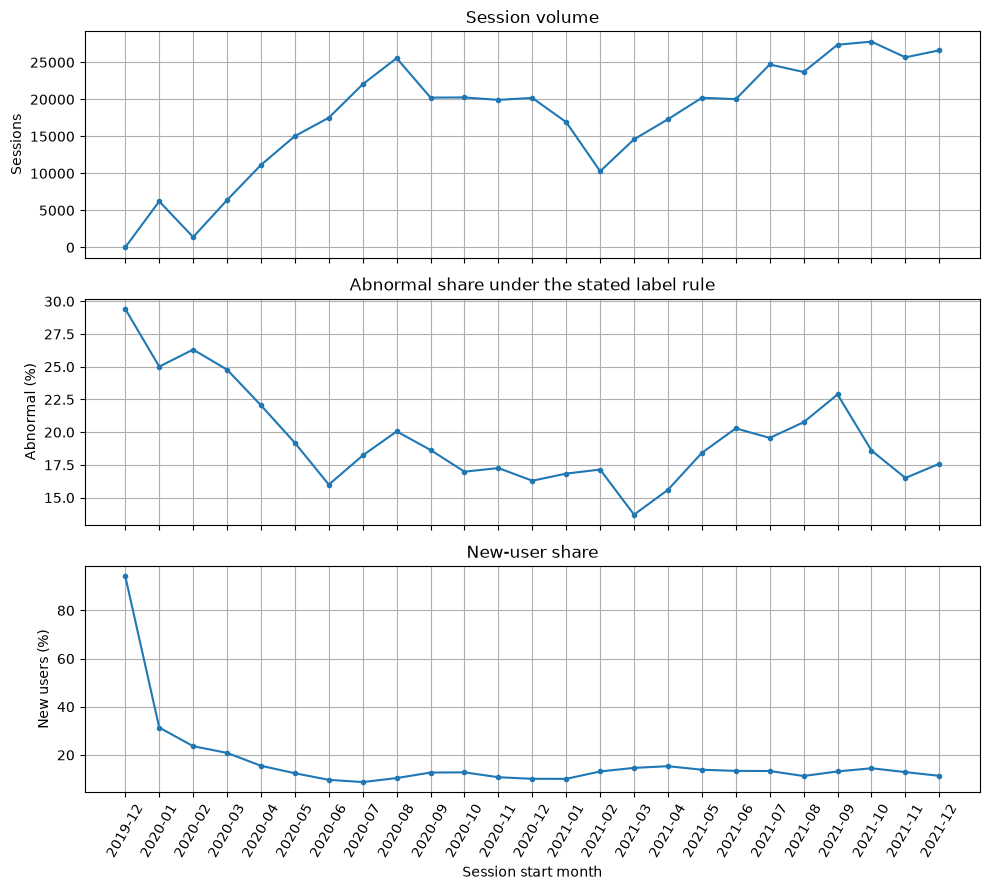

In [7]:
month = times["Start Time"].dt.to_period("M")
monthly = df.assign(month=month).groupby("month", observed=True).agg(
    sessions=("UserID", "size"),
    abnormal_sessions=("is_Abnormal", "sum"),
    abnormal_share=("is_Abnormal", "mean"),
    active_users=("UserID", "nunique"),
    active_posts=("Charging Post ID", "nunique"),
    median_temperature=("Temperature(℃)", "median"),
    median_post_sessions_30d=("post_previous_sessions_30D", "median"),
    new_user_share=("is_new_user", "mean"),
)
display(monthly.head(4))
display(monthly.tail(4))
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plot_months = monthly.index.astype(str)
for ax, values, label, title in [
    (axes[0], monthly["sessions"], "Sessions", "Session volume"),
    (axes[1], monthly["abnormal_share"] * 100, "Abnormal (%)", "Abnormal share under the stated label rule"),
    (axes[2], monthly["new_user_share"] * 100, "New users (%)", "New-user share"),
]:
    ax.plot(plot_months, values, marker="o", markersize=3)
    ax.set_ylabel(label)
    ax.set_title(title)
axes[-1].set_xlabel("Session start month")
axes[-1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

**Interpretation and decision.** Monthly volume changes substantially: January 2020 has 6,217 sessions, February 2020 has 1,391, and October 2021 reaches 27,794. The earliest month has only 17 records and should not guide comparisons. Under our label rule, monthly abnormal share ranges from 13.70% to 26.31% across full months. The new-user share is 31.4% in January 2020 and 11.3% in December 2021; median prior 30-day post sessions grow from 43 to 372. Temperature also changes with season. These patterns make random row splitting a poor simulation of future deployment. We propose chronological evaluation and a cold-start assessment. The trends may reflect coverage, infrastructure, seasonality, or a changing mix of users and posts; aggregates alone cannot establish a cause. All abnormal shares here inherit our target-mapping assumption.

## 7. Categorical scope and context

Location and tariff fields have few categories, while identifiers have many. This matters for future encoding: a raw user ID can memorise past users and creates a harder cold-start problem. We summarize counts here without revealing individual accounts.

In [8]:
for col in ["District Name", "Location Information", "tariff_period"]:
    counts = df[col].value_counts(dropna=False)
    print(f"{col}: {len(counts)} categories; smallest category = {counts.min():,} sessions")
    if col != "Location Information":
        display(counts.rename_axis(col).to_frame("sessions"))
print("Unique users:", df["UserID"].nunique())
print("Unique posts:", df["Charging Post ID"].nunique())
print("New-user rows:", int(df["is_new_user"].eq(1).sum()))
raw_locations = df["Location Information"].nunique()
trimmed_locations = df["Location Information"].str.strip().nunique()
whitespace_rows = df["Location Information"].ne(df["Location Information"].str.strip()).sum()
print("Location values with surrounding whitespace:", int(whitespace_rows))
print("Location categories before/after trimming:", raw_locations, trimmed_locations)

District Name: 3 categories; smallest category = 71,449 sessions


,sessions
District Name,
Tongxiang,220923
Xiuzhou,148705
Nanhu,71449


Location Information: 13 categories; smallest category = 12,401 sessions
tariff_period: 7 categories; smallest category = 22,843 sessions


,sessions
tariff_period,
peak_13_19,167118
off_peak_11_13,61760
peak_08_11,48977
off_peak_00_08,48633
sharp_19_21,48042
off_peak_22_24,43704
peak_21_22,22843


Unique users: 56115
Unique posts: 92
New-user rows: 56116
Location values with surrounding whitespace: 18370
Location categories before/after trimming: 13 13


**Interpretation and decision.** The file contains 3 districts, 13 locations, 7 tariff periods, 56,115 users, and 92 posts. One location label (`Industrial Park` with a trailing tab) affects 18,370 rows; trimming surrounding whitespace leaves the same 13 categories, so it is a safe presentation/encoding cleanup when needed. District and tariff are manageable categories; raw user identity is high cardinality and potentially sensitive. We keep IDs for audit and grouping, but defer their inclusion as predictors until we can assess privacy, unseen users/posts, and generalisation. No rare category is merged merely because it is small; first check its meaning and support within the training period.

### Explore the outcome alongside start-time context

A useful exploratory question is whether abnormal share differs across known-at-start groups. We compare districts and the provided new-user flag. The figures show descriptive associations, not the effect of changing district or account status. Differences could also reflect month, post, or user composition.

District Name


,sessions,abnormal,abnormal_share,abnormal_share_pct
District Name,,,,
Nanhu,71449,12691,0.177623,17.76
Tongxiang,220923,32591,0.147522,14.75
Xiuzhou,148705,36652,0.246475,24.65


tariff_period


,sessions,abnormal,abnormal_share,abnormal_share_pct
tariff_period,,,,
off_peak_00_08,48633,8941,0.183846,18.38
off_peak_11_13,61760,12649,0.204809,20.48
off_peak_22_24,43704,7874,0.180167,18.02
peak_08_11,48977,8589,0.175368,17.54
peak_13_19,167118,31996,0.191458,19.15
peak_21_22,22843,3842,0.168192,16.82
sharp_19_21,48042,8043,0.167416,16.74


is_new_user


,sessions,abnormal,abnormal_share,abnormal_share_pct
is_new_user,,,,
0,384961,70398,0.182870,18.29
1,56116,11536,0.205574,20.56


user_no_previous_completed_session


,sessions,abnormal,abnormal_share,abnormal_share_pct
user_no_previous_completed_session,,,,
0,384430,70227,0.182678,18.27
1,56647,11707,0.206666,20.67


post_no_previous_completed_session


,sessions,abnormal,abnormal_share,abnormal_share_pct
post_no_previous_completed_session,,,,
0,440985,81901,0.185723,18.57
1,92,33,0.358696,35.87


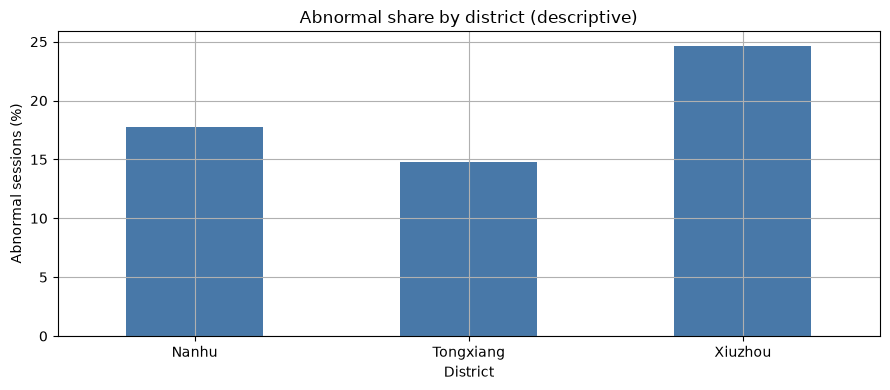

In [9]:
group_tables = {}
for col in ["District Name", "tariff_period", "is_new_user",
            "user_no_previous_completed_session", "post_no_previous_completed_session"]:
    group_tables[col] = df.groupby(col, dropna=False)["is_Abnormal"].agg(
        sessions="size", abnormal="sum", abnormal_share="mean"
    )
    print(col)
    display(group_tables[col].assign(abnormal_share_pct=lambda t: (t.abnormal_share * 100).round(2)))

ax = (group_tables["District Name"]["abnormal_share"] * 100).plot.bar(
    rot=0, color="#4878A8", title="Abnormal share by district (descriptive)"
)
ax.set_xlabel("District")
ax.set_ylabel("Abnormal sessions (%)")
plt.tight_layout()
plt.show()

**Interpretation and decision.** Under our label rule, abnormal share is 14.75% in Tongxiang, 17.76% in Nanhu, and 24.65% in Xiuzhou. New-user rows have 20.56% abnormal endings versus 18.29% among other rows. Post cold starts are only 92 sessions (33 abnormal), so their observed 35.87% is too sparse to treat as a stable estimate. District and history may be useful candidates, but these are unadjusted comparisons. We retain the groups for later evaluation, keep cold-start flags visible, and avoid claiming that a category causes an abnormal ending.

### Compare numeric start-time predictors with the outcome

Medians provide an initial, outlier-resistant summary. We choose forecast temperature and humidity, prior activity, and prior abnormal rates because they represent different kinds of start-time context. A difference between class medians is descriptive; it does not show how well a model will predict new sessions or whether one variable causes failure.

,normal median,abnormal median
Temperature(℃),20.600000,22.400000
Relative Humidity(%),76.000000,76.000000
Precipitation(mm),0.000000,0.000000
post_previous_sessions_30D,296.000000,278.000000
post_previous_abnormal_rate_30D,0.121827,0.252174
user_previous_sessions_30D,8.000000,5.000000
user_previous_abnormal_rate_30D,0.166667,0.200000


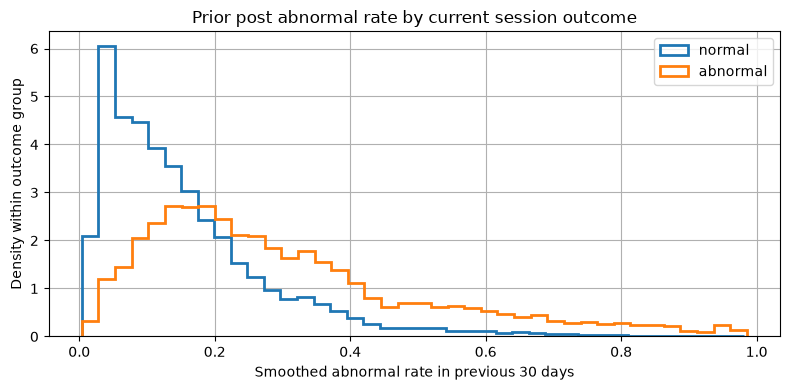

In [10]:
candidate_numeric = ["Temperature(℃)", "Relative Humidity(%)", "Precipitation(mm)",
                     "post_previous_sessions_30D", "post_previous_abnormal_rate_30D",
                     "user_previous_sessions_30D", "user_previous_abnormal_rate_30D"]
medians = df.groupby("is_Abnormal")[candidate_numeric].median().T
medians.columns = ["normal median", "abnormal median"]
display(medians)
fig, ax = plt.subplots(figsize=(8, 4))
for label, name in [(0, "normal"), (1, "abnormal")]:
    ax.hist(df.loc[df["is_Abnormal"].eq(label), "post_previous_abnormal_rate_30D"],
            bins=40, density=True, histtype="step", linewidth=2, label=name)
ax.set_title("Prior post abnormal rate by current session outcome")
ax.set_xlabel("Smoothed abnormal rate in previous 30 days")
ax.set_ylabel("Density within outcome group")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation and decision.** Median prior 30-day post abnormal rate is 0.122 for normal endings and 0.252 for abnormal endings. Prior user abnormal rate is 0.167 versus 0.200. Temperature medians are 20.6°C and 22.4°C, while humidity and precipitation medians are equal across the two groups. The plot shows different distributions of post history, supporting its inclusion as a candidate and the assignment's later feature-group ablation. History may reflect differences among posts and periods; no causal claim or performance estimate follows from this EDA. Zero median precipitation also suggests a concentration at no rain, so scaling or outlier treatment should not be automatic.

## 8. Preparation and evaluation decisions

The assignment requires a justified strategy; it does not reward cleaning for its own sake. This table separates actions supported by the audit from choices that need later modelling evidence.

| Issue | Evidence in this notebook | Decision | Status |
| --- | --- | --- | --- |
| Binary target absent from source | Section 2: 15 termination reasons | Derive `is_Abnormal` in memory using two intentional endings as 0 and 13 fault/failure endings as 1; state sensitivity to user-stop interpretation | Adopted for EDA; instructor confirmation pending |
| Prediction-time leakage | Section 2 field audit and assignment timing rule | Exclude outcome and final transaction fields from predictors | Adopted |
| Full-row or key duplicates | Section 4: zero detected | Remove none | Adopted |
| Zero delivered energy | Section 4: 54,621 rows, many fault endings | Retain as a plausible outcome; exclude energy from predictors | Adopted |
| Timestamp order anomalies | Section 3: order/start and end/payment mismatches | Retain; investigate semantics; avoid affected timing features | Provisional |
| Final payment mismatch | Section 4: 45,812 differ from listed amount | Retain and investigate; never use final payment as predictor | Provisional |
| No prior completed event | Section 5: flags exactly match missing elapsed values | Preserve flags and distinguish absent history from zero elapsed time | Adopted |
| Changes over time | Section 6: changing volume, abnormal share, and user mix | Use chronological evaluation; study cold starts and temporal stability | Proposed |
| Location label whitespace | Section 7: trailing tab in 18,370 rows, no new category after trim | Trim whitespace for later categorical encoding; preserve raw CSV | Adopted |
| High-cardinality IDs | Section 7: 56,115 users and 92 posts | Keep as audit keys; decide predictive use after generalisation/privacy review | Pending |

For later modelling, we propose calendar boundaries chosen for operational realism: training through 2020, validation January–June 2021, and final test July–December 2021; the 17 rows from December 2019 belong to training. **These are a design proposal, not a model evaluated in Task 1.** A session's label should be known by the training cutoff before that row contributes to model fitting. Any learned imputation, scaling, category grouping, outlier threshold, feature selection, or resampling must be fitted on training data only; validation/test receive the fitted transformations. Resampling, if justified, belongs only inside training. No such operation has been fitted here.

## Task 1 synthesis

**What we learned.** The supplied dataset has 441,077 sessions across roughly two calendar years. The original file has no binary target, so we made a transparent EDA definition: 81,934 fault/failure endings are abnormal (18.58%), while ordinary endings and user-requested stops are normal. This assumption is sensitive: making user stops abnormal raises prevalence to 53.93%. Most fields are complete; four elapsed-history fields have explicit “no previous event” missingness. We found no exact or user/post/start duplicates, no unparseable timestamps, and no violations in the tested history counts/rates. Order/start and end/payment timing deserve semantic review. Monthly activity, abnormal share, and new-user mix vary substantially; district and new-user comparisons show associations that need careful later evaluation. We retained all records and kept post-session fields out of the candidate predictor set. Prior post abnormal history differs by current outcome and warrants later ablation. A trailing tab affects one location label; trimming it does not change the number of categories.

**Preparation conclusion.** For this EDA stage, the only derived field is `is_Abnormal`; trimming location-label whitespace is the only proposed text cleanup. No imputation, capping, deletion, category merging, or model fitting was justified. For future modelling, retain start-time context and the provided histories as candidate groups, preserve cold-start flags, and decide on identifiers after privacy/generalisation review. Use chronological evaluation and fit any learned preparation only within training data. The instructor's exact target interpretation, timestamp/payment semantics, and operational availability of histories remain limitations. Historical-feature ablation is required later; it is not claimed as an EDA result.

The [report draft](docs/TASK1_REPORT.md), [team plan](docs/PLAN.md), and [memory](docs/MEMORY.md) keep the decisions and open items available to everyone.